In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Load from the Data_preprocessing folder inside Customer_churn_analysis
df = pd.read_csv('/content/drive/MyDrive/Customer_churn_analysis/Data_preprocessing/churn_cleaned.csv')

print("Data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Mounted at /content/drive
Data shape: (7043, 10)

First few rows:
   gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0       0              0           0       1             0              0   
1       1              0           0      41             1              0   
2       0              0           1      52             1              0   
3       0              0           0       1             1              0   
4       1              0           0      67             1              0   

   InternetService  Contract  MonthlyCharges  Churn  
0                0         0              25      1  
1                0         1              25      0  
2                0         0              19      0  
3                0         1              76      1  
4                1         0              51      0  

Column names:
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges'

In [4]:
print(df.head())
print(df.shape)

   gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0       0              0           0       1             0              0   
1       1              0           0      41             1              0   
2       0              0           1      52             1              0   
3       0              0           0       1             1              0   
4       1              0           0      67             1              0   

   InternetService  Contract  MonthlyCharges  Churn  
0                0         0              25      1  
1                0         1              25      0  
2                0         0              19      0  
3                0         1              76      1  
4                1         0              51      0  
(7043, 10)


In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = Sequential()

model.add(Dense(16, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6969 - loss: 0.5904 - val_accuracy: 0.7826 - val_loss: 0.4869
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7675 - loss: 0.4773 - val_accuracy: 0.8004 - val_loss: 0.4481
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7797 - loss: 0.4561 - val_accuracy: 0.7968 - val_loss: 0.4382
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7861 - loss: 0.4493 - val_accuracy: 0.8021 - val_loss: 0.4353
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7901 - loss: 0.4471 - val_accuracy: 0.7933 - val_loss: 0.4349
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7894 - loss: 0.4451 - val_accuracy: 0.8030 - val_loss: 0.4341
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7914 - loss: 0.4436 - val_accuracy: 0.8021 - val_loss: 0.4334
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7941 - loss: 0.4422 - val_accuracy: 0.

In [10]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7954 - loss: 0.4294 - val_accuracy: 0.7959 - val_loss: 0.4389
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7979 - loss: 0.4287 - val_accuracy: 0.7950 - val_loss: 0.4391
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.4286 - val_accuracy: 0.7950 - val_loss: 0.4387
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7981 - loss: 0.4288 - val_accuracy: 0.7977 - val_loss: 0.4390
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7934 - loss: 0.4291 - val_accuracy: 0.7950 - val_loss: 0.4392
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7981 - loss: 0.4282 - val_accuracy: 0.7933 - val_loss: 0.4397
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7941 - loss: 0.4281 - val_accuracy: 0.7950 - val_loss: 0.4389
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7968 - loss: 0.4279 - val_accuracy: 0.

In [13]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7807 - loss: 0.4563
Loss: 0.4563167989253998
Accuracy: 0.7806955575942993


In [14]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [15]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.7806955287437899

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix:
[[926 109]
 [200 174]]


In [16]:
model.save("ann_model.h5")

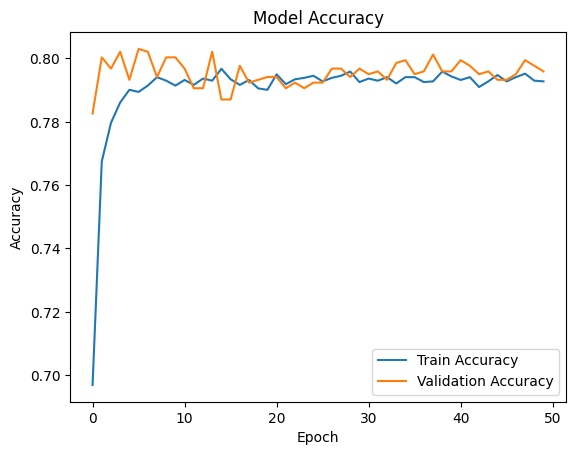

In [17]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

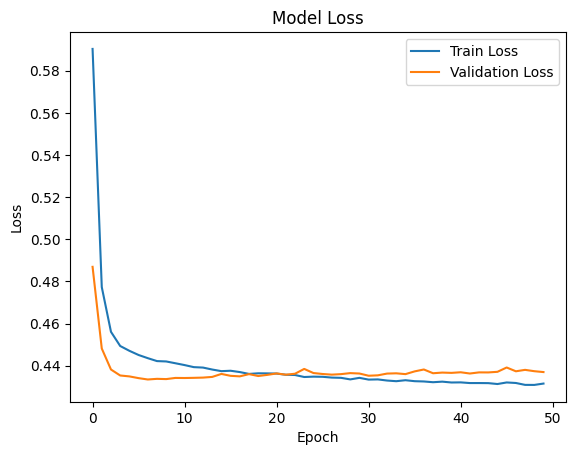

In [18]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred.flatten()
})

predictions.to_csv("ann_predictions.csv", index=False)

In [20]:
from google.colab import files

files.download("ann_model.h5")
files.download("ann_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import pandas as pd
import numpy as np
from google.colab import files

# Save the model
model.save("ann_model.h5")
print("Model saved as ann_model.h5")

# Create predictions dataframe
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Create predictions CSV
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred.flatten(),
    'Probability': y_pred_prob.flatten()
})

predictions_df.to_csv("ann_predictions.csv", index=False)
print("Predictions saved as ann_predictions.csv")

# Now download both files
files.download("ann_model.h5")
files.download("ann_predictions.csv")

print("Download complete")

Model saved as ann_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predictions saved as ann_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete
